# 01 — Monthly Sales Trend
Sales and profit plotted month-by-month across the full dataset period.


In [3]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


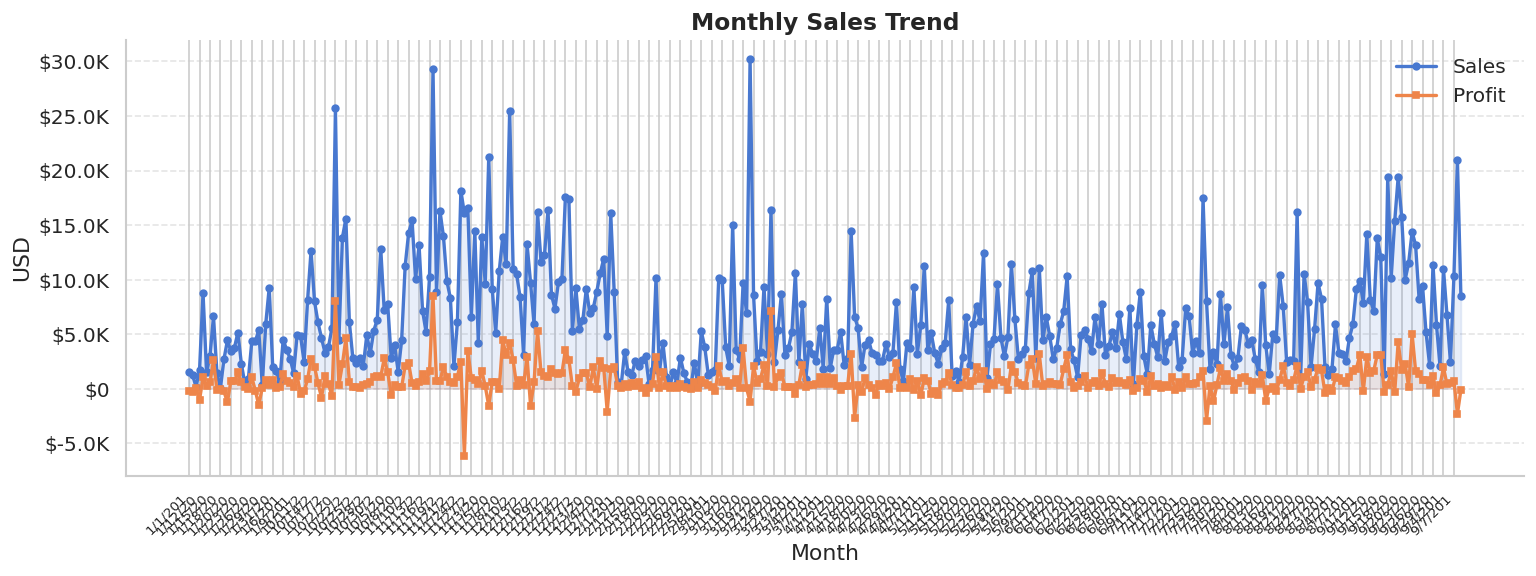

In [2]:
# ── Monthly Sales Trend ───────────────────────────────────────────────────────
monthly = fetch_df(cur, """
    SELECT SUBSTR(o.order_date, 1, 7)  AS month,
           ROUND(SUM(oi.sales),  2)    AS sales,
           ROUND(SUM(oi.profit), 2)    AS profit
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY SUBSTR(o.order_date, 1, 7)
    ORDER BY month
""")

tick_pos    = list(range(0, len(monthly), 3))
tick_labels = [monthly["month"].iloc[i] for i in tick_pos]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(range(len(monthly)), monthly["sales"],
                alpha=0.12, color=PALETTE[0])
ax.plot(range(len(monthly)), monthly["sales"], marker="o", markersize=4,
        color=PALETTE[0], linewidth=2, label="Sales")
ax.fill_between(range(len(monthly)), monthly["profit"],
                alpha=0.12, color=PALETTE[1])
ax.plot(range(len(monthly)), monthly["profit"], marker="s", markersize=4,
        color=PALETTE[1], linewidth=2, label="Profit")

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.legend(frameon=False)
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [3]:
cur.close()
conn.close()
print("Done.")


Done.
